# Rat consolidation: comparison with Figure 12

A 16 → 16 → 16 cortical network learns a new association through replay among 20 background associations. We fit its learning rate to the four behavioral means plotted in McClelland et al. (1995), Figure 12b.

The behavioral values are **approximate readings from the published figure**, not raw animal data. New random seeds test simulation robustness; they do not provide independent behavioral validation.

This notebook is self-contained. Upload it to Colab and run all cells; CPU is sufficient. No Drive mount or project files are required.

## Setup

In [1]:
# Locate shared data when opened from this notebook folder or the project root.
from pathlib import Path
import os, sys
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if (p / 'data' / 'targets.csv').is_file()), Path.cwd())
os.chdir(project_root)
sys.path.insert(0, str(project_root / 'notebooks' / 'semantic'))

import io
import json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(1)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

## 1. Behavioral comparison

The animals received hippocampal lesions 1, 7, 14 or 28 days after conditioning and were tested seven days later. Figure 12b normalizes freezing in lesioned animals by the mean control response. Here we read the normalized panel directly.

The table contains approximate marker centers and plotted error-bar endpoints, rounded to 0.01. Reading uncertainty is roughly 0.01; the error bars are displayed as published, without assigning them a confidence level.

In [2]:
data = pd.read_csv(io.StringIO('day,mean,lower,upper\n1,0.09,0.07,0.11\n7,0.40,0.24,0.55\n14,0.38,0.22,0.54\n28,0.65,0.45,0.85\n'))
data

,day,mean,lower,upper
0,1,0.09,0.07,0.11
1,7,0.40,0.24,0.55
2,14,0.38,0.22,0.54
3,28,0.65,0.45,0.85


## 2. Cortical learning

The network first learns 20 background pairs. Every simulated day then presents each background pair and the new ETS pair once, in random order. The hippocampus is represented by the source of ETS replay.

This implementation uses 100 background pretraining epochs, sigmoid units, 0.05/0.95 targets, biases, and online SGD. The original random patterns and fitted learning rate were not supplied. We keep these choices fixed and fit only the learning rate.

In [3]:
def make_data(seed=0):
    rng = np.random.default_rng(seed)
    inputs = rng.integers(0, 2, (21, 16))
    targets = .05 + .9 * rng.integers(0, 2, (21, 16))
    return torch.tensor(inputs, dtype=torch.float64), torch.tensor(targets, dtype=torch.float64)

class RatNetwork(nn.Sequential):
    def __init__(self, seed=0):
        with torch.random.fork_rng():
            torch.manual_seed(seed)
            super().__init__(nn.Linear(16, 16), nn.Sigmoid(),
                             nn.Linear(16, 16), nn.Sigmoid())
            self.double()
            for parameter in self.parameters():
                nn.init.uniform_(parameter, -.5, .5)

def train_epoch(model, optimizer, inputs, targets, order):
    for i in order:
        optimizer.zero_grad()
        loss = .5 * (model(inputs[i]) - targets[i]).square().sum()
        loss.backward()
        optimizer.step()

def run(seed=0, learning_rate=.3, pretraining_epochs=100, days=28, lesion_day=None):
    """One epoch/day. Optional lesion stops ETS replay after that day's training.

    Default records cortical performance at each delay, as in Figure 12b.
    lesion_day is an additional intervention for testing the replay mechanism.
    """
    if days < 0 or pretraining_epochs < 0 or learning_rate < 0:
        raise ValueError('Training parameters must be non-negative.')
    if lesion_day is not None and not 0 <= lesion_day <= days:
        raise ValueError('lesion_day must be between 0 and days.')
    inputs, targets = make_data(seed)
    model = RatNetwork(seed)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    order_rng = np.random.default_rng(seed + 10000)
    for _ in range(pretraining_epochs):
        train_epoch(model, optimizer, inputs, targets, order_rng.permutation(20))
    records = []
    for day in range(days + 1):
        if day:
            order = order_rng.permutation(21)
            if lesion_day is not None and day > lesion_day:
                order = order[order != 20]
            train_epoch(model, optimizer, inputs, targets, order)
        with torch.no_grad():
            output = model(inputs)
            records.append(dict(day=day, output=output[-1].tolist(),
                                hidden=torch.sigmoid(model[0](inputs[-1])).tolist(),
                                mse=(output[-1] - targets[-1]).square().mean().item(),
                                background_mse=(output[:20] - targets[:20]).square().mean().item()))
    for frame in records:
        frame['score'] = 1 - frame['mse'] / records[0]['mse']
    return dict(seed=seed, learning_rate=learning_rate, pretraining_epochs=pretraining_epochs,
                lesion_day=lesion_day, inputs=inputs.tolist(), targets=targets.tolist(), frames=records)

The cortical score is

$$s(t)=1-rac{mathrm{MSE}(t)}{mathrm{MSE}(0)}.$$

It measures the fraction of initial ETS error removed. The original simulation compares cortical acquisition at each delay with the lesion data; it does not explicitly simulate the seven-day postsurgical interval.

### Independent-network batch helper

In [4]:
def simulate(seeds, learning_rates, pretraining_epochs=100, days=28):
    seeds, learning_rates = list(seeds), list(learning_rates)
    assert len(seeds) == len(learning_rates)
    models = [RatNetwork(seed) for seed in seeds]
    p = nn.ParameterList([nn.Parameter(torch.stack([list(m.parameters())[j].detach() for m in models])) for j in range(4)])
    x, y = [torch.stack(a) for a in zip(*(make_data(s) for s in seeds))]
    rngs = [np.random.default_rng(s + 10000) for s in seeds]
    rates = torch.tensor(learning_rates, dtype=torch.float64)
    optimizer = torch.optim.SGD(p, lr=1.)
    rows = torch.arange(len(seeds))
    def forward(z):
        h = torch.sigmoid(torch.bmm(p[0], z.unsqueeze(-1)).squeeze(-1) + p[1])
        return torch.sigmoid(torch.bmm(p[2], h.unsqueeze(-1)).squeeze(-1) + p[3])
    def epoch(n):
        order = np.stack([rng.permutation(n) for rng in rngs])
        for step in range(n):
            index = torch.tensor(order[:, step])
            optimizer.zero_grad()
            loss = (.5 * (forward(x[rows, index]) - y[rows, index]).square().sum(-1) * rates).sum()
            loss.backward()
            optimizer.step()
    for _ in range(pretraining_epochs):
        epoch(20)
    errors = []
    for day in range(days + 1):
        if day:
            epoch(21)
        with torch.no_grad():
            errors.append((forward(x[:, 20]) - y[:, 20]).square().mean(-1).numpy())
    errors = np.stack(errors, axis=1)
    return 1 - errors / errors[:, :1]

## 3. Fit one parameter

We search 25 learning rates from 0.05 to 0.65, minimizing unweighted squared error at the four delays. Each candidate uses the same 16 seeds (0–15). All seeds contribute to the mean; no individual run is selected for its fit.

In [5]:
def fit(data, rates=np.linspace(.05, .65, 25), seeds=range(16)):
    rates, seeds = np.asarray(rates), list(seeds)
    values = simulate(seeds * len(rates), np.repeat(rates, len(seeds)))
    curves = values.reshape(len(rates), len(seeds), 29)
    means = curves.mean(1)
    mse = ((means[:, data.day.to_numpy()] - data['mean'].to_numpy())**2).mean(1)
    index = int(mse.argmin())
    return float(rates[index]), curves[index], pd.DataFrame({'learning_rate': rates, 'rmse': np.sqrt(mse)})

learning_rate, calibration, grid = fit(data)
print(f'Selected learning rate: {learning_rate:.3f}')
grid.sort_values('rmse').head()

Selected learning rate: 0.350


,learning_rate,rmse
12,0.350,0.057277
13,0.375,0.057687
11,0.325,0.058183
14,0.400,0.059644
10,0.300,0.061273


## 4. Comparison on new random seeds

The fitted learning rate is fixed for 64 new seeds (100–163). The shaded band shows the 10th–90th percentiles across networks, not an animal-data confidence interval. Both curves are compared with the same four behavioral means used for fitting.

,day,mean,lower,upper,model_mean,residual,inside_plotted_bar
0,1,0.09,0.07,0.11,0.1163,0.0263,False
1,7,0.40,0.24,0.55,0.3957,-0.0043,True
2,14,0.38,0.22,0.54,0.5254,0.1454,True
3,28,0.65,0.45,0.85,0.6552,0.0052,True


RMSE: 0.0740; mean inside plotted error bars: 3/4


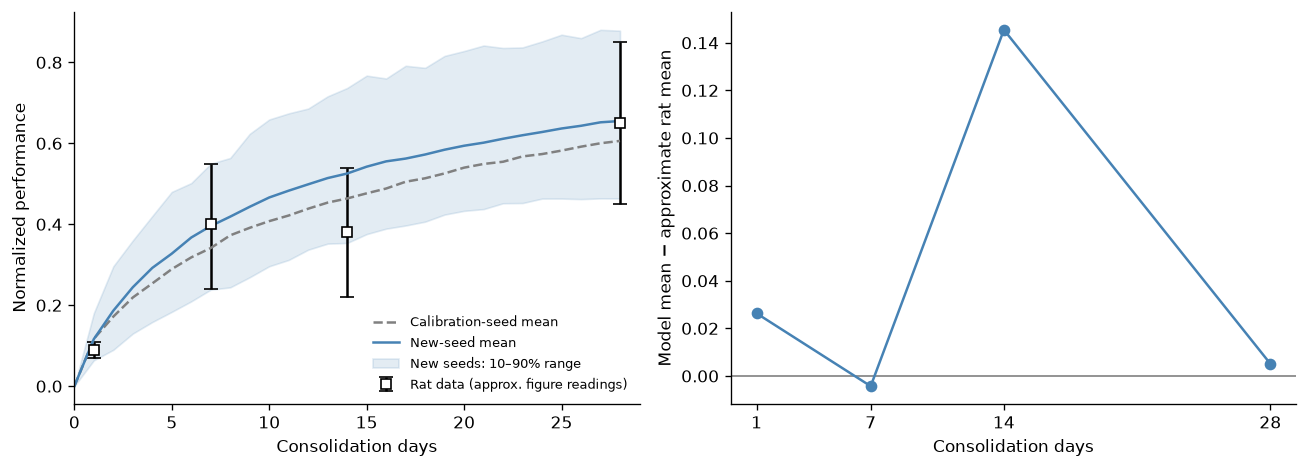

In [6]:
audit = simulate(range(100, 164), [learning_rate] * 64)
days = np.arange(29)
mean = audit.mean(0)
low, high = np.quantile(audit, [.1, .9], axis=0)
test_days = data.day.to_numpy()
comparison = data.assign(model_mean=mean[test_days], residual=mean[test_days] - data['mean'])
comparison['inside_plotted_bar'] = (comparison.model_mean >= comparison.lower) & (comparison.model_mean <= comparison.upper)
rmse = np.sqrt(np.mean(comparison.residual**2))
display(comparison.round(4))
print(f'RMSE: {rmse:.4f}; mean inside plotted error bars: {comparison.inside_plotted_bar.sum()}/4')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(data.day, data['mean'], yerr=[data['mean']-data.lower, data.upper-data['mean']],
                 fmt='s', mfc='white', color='black', capsize=4, label='Rat data (approx. figure readings)')
axes[0].plot(days, calibration.mean(0), '--', color='gray', label='Calibration-seed mean')
axes[0].plot(days, mean, color='steelblue', label='New-seed mean')
axes[0].fill_between(days, low, high, color='steelblue', alpha=.15, label='New seeds: 10–90% range')
axes[0].set(xlabel='Consolidation days', ylabel='Normalized performance', xlim=(0,29))
axes[0].legend(frameon=False, fontsize=8)
axes[1].axhline(0, color='gray', lw=1)
axes[1].plot(test_days, comparison.residual, 'o-', color='steelblue')
axes[1].set(xlabel='Consolidation days', ylabel='Model mean − approximate rat mean', xticks=test_days)
fig.tight_layout()
destination = Path('outputs/rat')
destination.mkdir(parents=True, exist_ok=True)
fig.savefig(destination / 'figure12_comparison.png', bbox_inches='tight')
plt.show()

## 5. Pretraining sensitivity

The original background pretraining duration is unspecified. We vary it here while keeping the fitted learning rate fixed. This shows how much the result depends on an implementation choice.

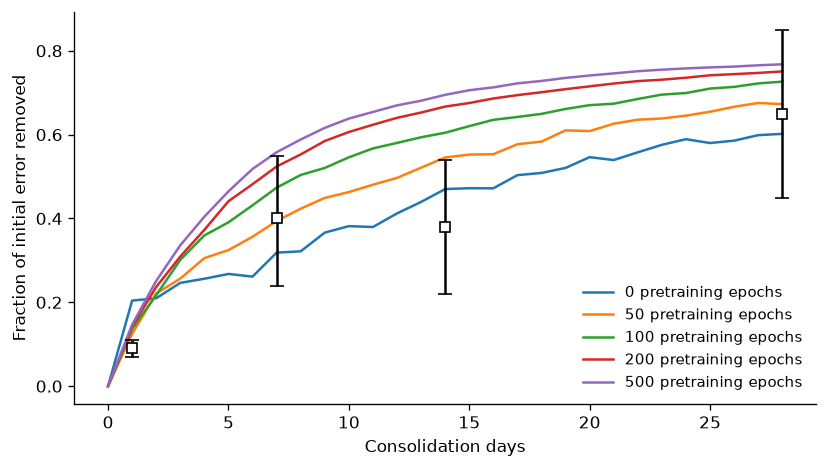

In [7]:
sensitivity = {p: simulate(range(100,116), [learning_rate]*16, pretraining_epochs=p).mean(0)
               for p in [0, 50, 100, 200, 500]}
fig, ax = plt.subplots(figsize=(7, 4))
for epochs, curve in sensitivity.items():
    ax.plot(days, curve, label=f'{epochs} pretraining epochs')
ax.errorbar(data.day, data['mean'], yerr=[data['mean']-data.lower, data.upper-data['mean']],
            fmt='s', mfc='white', color='black', capsize=4)
ax.set(xlabel='Consolidation days', ylabel='Fraction of initial error removed')
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(destination / 'pretraining_sensitivity.png', bbox_inches='tight')
plt.show()

## 6. Inspect a single association

Select a day to inspect the input, hidden activity, prediction, and target for seed 100. The marker follows this individual network, not the ensemble mean.

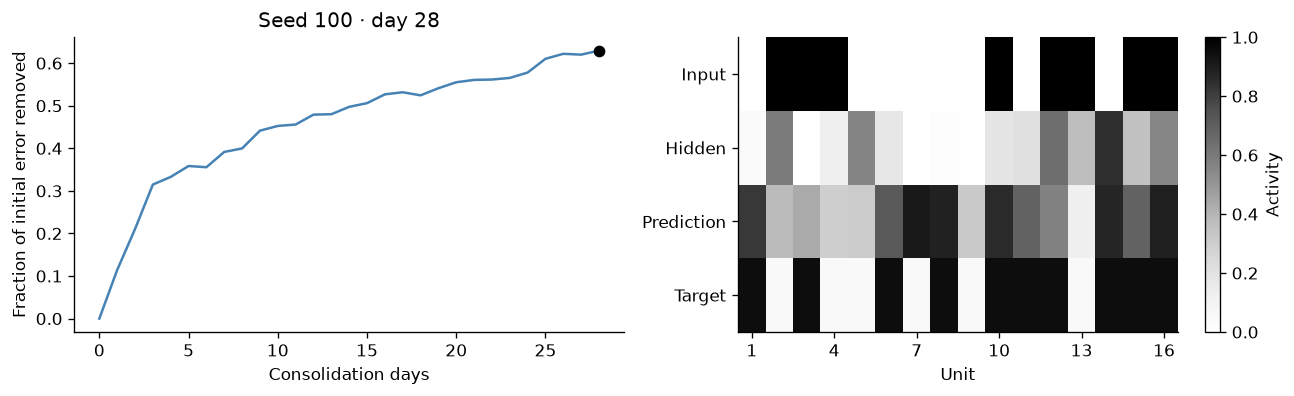

interactive(children=(IntSlider(value=0, continuous_update=False, description='day', max=28), Output()), _dom_…

In [8]:
example = run(seed=100, learning_rate=learning_rate)
def show_day(day=0):
    frame = example['frames'][day]
    values = np.array([example['inputs'][-1], frame['hidden'], frame['output'], example['targets'][-1]])
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
    axes[0].plot(days, [f['score'] for f in example['frames']], color='steelblue')
    axes[0].scatter([day], [frame['score']], color='black', zorder=3)
    axes[0].set(xlabel='Consolidation days', ylabel='Fraction of initial error removed', title=f'Seed 100 · day {day}')
    im = axes[1].imshow(values, cmap='Greys', vmin=0, vmax=1, aspect='auto')
    axes[1].set(yticks=range(4), yticklabels=['Input', 'Hidden', 'Prediction', 'Target'],
                xticks=range(0,16,3), xticklabels=range(1,17,3), xlabel='Unit')
    fig.colorbar(im, ax=axes[1], label='Activity')
    fig.tight_layout()
    plt.show()

show_day(28)
try:
    import ipywidgets as widgets
    display(widgets.interactive(show_day, day=widgets.IntSlider(value=0, min=0, max=28, continuous_update=False)))
except ImportError:
    print('Call show_day(0), show_day(7), or show_day(28); install ipywidgets for the slider.')

## Save results

The fitted curve is a reconstruction of the consolidation mechanism, not a recovery of the authors' weights. Approximate figure readings and the four-point calibration limit the strength of the comparison.

In [9]:
comparison.to_csv(destination / 'figure12_comparison.csv', index=False)
grid.to_csv(destination / 'fit_grid.csv', index=False)
np.savez(destination / 'figure12_curves.npz', calibration=calibration, audit=audit, learning_rate=learning_rate)
(destination / 'figure12_run_settings.json').write_text(json.dumps({
    'learning_rate': learning_rate, 'pretraining_epochs': 100,
    'calibration_seeds': list(range(16)), 'audit_seeds': list(range(100,164)),
    'rmse': float(rmse), 'data': 'Approximate Figure 12b readings, not raw data'
}, indent=2), encoding='utf-8')

892

## Sources

McClelland, J. L., McNaughton, B. L., & O'Reilly, R. C. (1995). *Psychological Review*, 102, 419–457. [DOI](https://doi.org/10.1037/0033-295X.102.3.419). Figure 12b, p. 442.

Kim, J. J., & Fanselow, M. S. (1992). Modality-specific retrograde amnesia of fear. *Science*, 256, 675–677. [DOI](https://doi.org/10.1126/science.1585183).

Approximate normalized means at days 1, 7, 14, 28: 0.09, 0.40, 0.38, 0.65. Approximate lower/upper plotted endpoints: (0.07, 0.11), (0.24, 0.55), (0.22, 0.54), (0.45, 0.85). Read manually from the published normalized panel; values rounded to 0.01.